La funzione è DEBLUR, fa:
$$y^\delta = Ax + w \implies \min_{x \in \R^n} \|Ax-y^\delta\|^2_2 \implies A^TAx = A^Ty^\delta$$
Dove:
- $x$ è l'immagine
- $A$ è la funzione di convoluzione (con il kernel)
- $w$ è rumore
- $y^\delta$ è l'immagine sfocata

Risolvendo con la regola dei minimi quadrati, succede che l'immagine non riesce a trovare la soluzione, dato che cercando $y^\delta$ stiamo anche trovando il rumore, l'immagine comincia a trovare dei risultati assurdi.

Al posto di minimizzare $\min_{x \in \R^n} \|Ax-y^\delta\|^2_2$, lo faccio con un parametro $\lambda R(x)$, ovvero un "freno":

$$\min_{x \in \R^n} \|Ax-y^\delta\|^2_2+\lambda R(x), \quad \lambda > 0$$

$R(x) = $ Lx 

Quindi $\min \limits_{x_{\lambda} \in \R^n} \|Ax_\lambda-y^\delta\|^2_2 \approx 1.01 \|w\|^2_2$

La regolarizzazione di Tikhanov:
$$\min_{x \in \R^n} \|Ax-y^\delta\|^2_2+\lambda \|x\|^2_2 \implies (A^TA+\lambda I)x = A^Ty^\delta$$

## REGOLARIZZAZIONE CON VARIAZIONE TOTALE

Il difetto principale di Tikhonov è che odia i cambiamenti bruschi. Se c'è un bordo netto (es. la spalla scura del "Cameraman" contro il cielo chiaro), Tikhonov cerca di "addolcirlo" per ridurre l'energia. Risultato Tikhonov: Immagine senza rumore, ma sfocata sui bordi.

La Variazione Totale $TV(x)$ non guarda quanto sono grandi i valori dei pixel, ma somma i valori assoluti delle differenze tra pixel vicini.

$$TV(x)=||\nabla(x)||_1=\sum_{i=1}^M\sum_{j=1}^n \sqrt{(x_{i+1,j}-x_{i,j})^2+(x_{i,j+1}-x_{i,j})^2}$$

La funzione non è differenziabile nel punto $(0,0)$ (immagina la funzione come cono). Per ottenere la differenziabilità si pone $\beta>0$ e si scrive:

$$TV^{\beta}(x)=\sum_{i=1}^m\sum_{j=1}^n \sqrt{(x_{i+1,j}-x_{i,j})^2+(x_{i,j+1}-x_{i,j})^2+\beta^2}$$

Di solito $\beta$ è circa $10^{-3}$

Il problema di regolarizzazione diventa quindi:

$$min_x ||Ax-y^{\delta}||_2^2+\lambda TV^{\beta}(x)$$

È differenziabile e convessa, quindi **possiamo applicare il metodo del gradiente**

Guardati ER, PSNR, SSIM.
Il grafico con \lambda nelle x e ER nelle y, si ha un grafico convesso con \lambda* come minimo globale

## Import Librerie

In [62]:
from ProblemiInversi import operators, solvers, utilities
import numpy as np
from numpy.linalg import svd
import matplotlib.pyplot as plt

from skimage import data

## Compressione file con SVD

Dimensioni dell'immagine: 512 x 512
Rango massimo possibile: 512


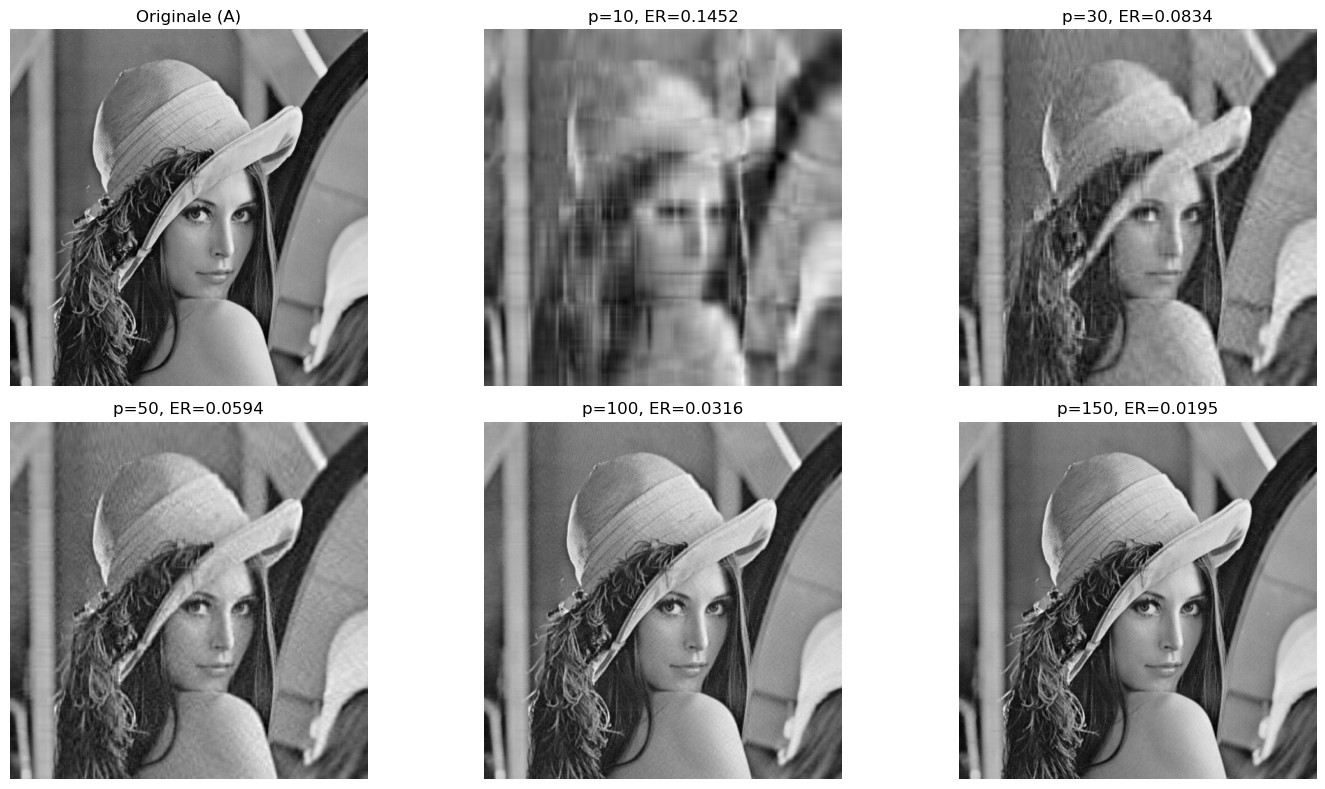

In [63]:
# Lettura dati da file immagine
x=plt.imread("lena.bmp")

nx, ny = x.shape
rank=min(nx,ny)

print(f"Dimensioni dell'immagine: {nx} x {ny}")
print(f"Rango massimo possibile: {rank}")

# Calcolo SVD
U, s, Vt = svd(x, full_matrices=False)

# Inizializzo i dati
p_arr = [10, 30, 50, 100, 150]
errors = []
compressions = []
reconstructions = []

# Per ER
norm_A = np.linalg.norm(x)

# Funzione A_p
for i in p_arr:
    # --- Calcolo della matrice A_p ---
    S_p = np.diag(s[:i])
    A_p = U[:, :i] @ S_p @ Vt[:i, :]
    reconstructions.append(A_p)
    
    # --- Calcolo dell'errore relativo in norma 2 ---
    diff_norm = np.linalg.norm(x - A_p)
    rel_error = diff_norm / norm_A
    errors.append(rel_error)
    
    # --- Calcolo del fattore di compressione cp ---
    cp = (1/i) * rank - 1
    compressions.append(cp)

plt.figure(figsize=(15, 8))

# Mostra Originale
plt.subplot(2, 3, 1)
plt.imshow(x, cmap='gray')
plt.title("Originale (A)")
plt.axis('off')

# Mostra le ricostruzioni per i vari p
for i, p in enumerate(p_arr):
    plt.subplot(2, 3, i + 2)
    plt.imshow(reconstructions[i], cmap='gray')
    plt.title(f"p={p}, ER={np.round(errors[i],4)}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Sfocamento

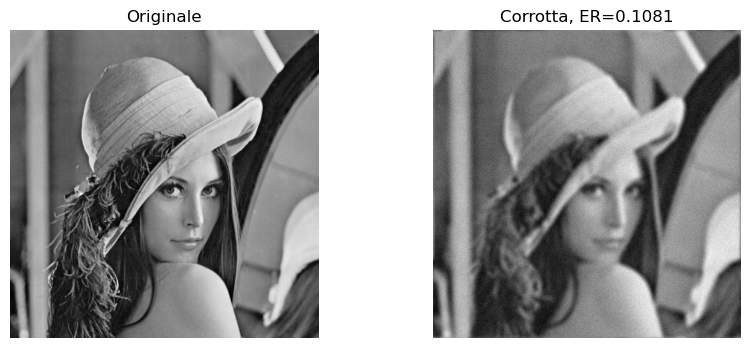

In [64]:
# Definizione kernel di blur e operatore associato
kernel = utilities.gaussian2d_kernel(k=11, sigma=3.5)
A = operators.ConvolutionOperator(kernel)

# Sfocatura dell'immagine
y = A(x)

# Aggiunta rumore
y_delta = y + utilities.gaussian_noise(y, noise_level=0.05)

ER_sfocatura=np.round(utilities.rel_err(y_delta,x),5)

# Show della sfocatura
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(x, cmap="gray")
plt.title("Originale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y_delta, cmap="gray")
plt.axis("off")
plt.title(f"Corrotta, ER={ER_sfocatura}")
plt.show()

## Ricostruzione Naive CGLS

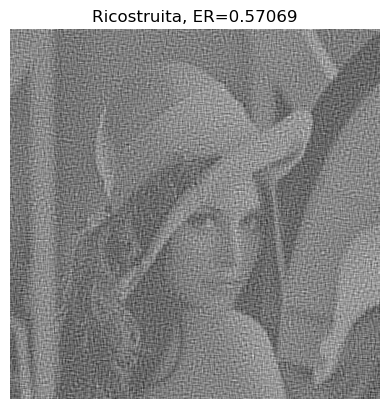

In [65]:
cgls_solver = solvers.CGLS(A)

# Scelta di x0, kmax, tolf, tolx
x0 = np.zeros_like(x)
kmax = 30
tolf = 1e-8
tolx = 1e-8

# Soluzione
x_cgls = cgls_solver.solve(y_delta, x0, kmax, tolf, tolx)

# ER naive
ER_naive=np.round(utilities.rel_err(x_cgls,x),5)

# Show della ricostruzione
plt.imshow(x_cgls, cmap="gray")
plt.axis("off")
plt.title(f"Ricostruita, ER={ER_naive}")
plt.show()

## Ricostruzione Tikhonov

In [87]:
# Calcolo soluzione regolarizzata con il metodo di Tikhonov e lambda fissato
# Problema di minimo risolto con CGLS

lambdas = np.logspace(-5, 1, 20) # Cambio in linspace?

errors_bk = []  # Errore rispetto al Ground Truth (x)
residuals = []  # Residuo rispetto ai dati misurati (y_delta)
solutions = []  # Salviamo le soluzioni

# Sappiamo che y_delta = y + rumore. Quindi la norma del rumore è ||y_delta - y||
noise_norm = np.linalg.norm(y_delta - y) # Lo dobbiamo proprio fare?

# Scelta di x0, kmax, tolf, tolx
x0 = np.zeros_like(x)
kmax = 40
tolf = 1e-8
tolx = 1e-8

# Inizio calcolo
for i in lambdas:
    L = operators.Identity()
    M = operators.TikhonovOperator(A, L, i)

    ybar_delta = np.pad(y_delta, ((0, nx), (0, 0)))

    cgls_tik_solver = solvers.CGLS(M)
    x_tik = cgls_tik_solver.solve(ybar_delta, x0, kmax, tolf, tolx)
    
    # 1. Errore di ricostruzione (norma 2 tra soluzione e ground truth)
    err_val = np.linalg.norm(x_tik - x) # Non / x?
    errors_bk.append(err_val)
    
    # 2. Norma del residuo sui DATI (non sul sistema aumentato!)
    # Calcoliamo || A(x_tik) - y_delta ||
    res_val = np.linalg.norm(A(x_tik) - y_delta)
    residuals.append(res_val)
    
    solutions.append(x_tik)


Lambda (Minimo Errore): 1.27e-01
Errore minimo: 6083.8420
Lambda (Discrepanza): 1.27e-01
Residuo al lambda discrepanza: 3454.4973


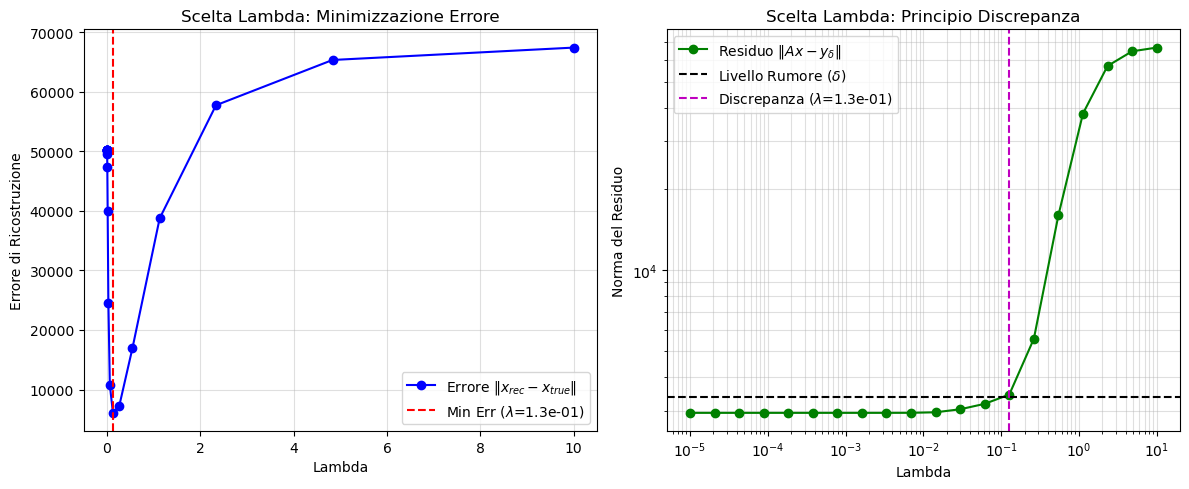

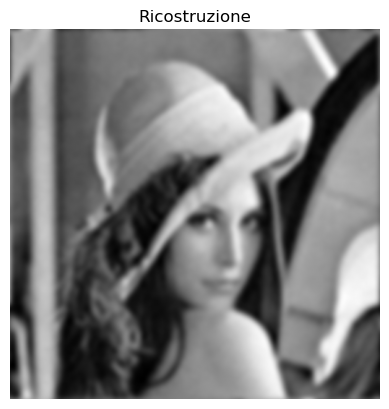

ER 0.9902936174781902
PSNR -42.38973197049786
SSIM 0.6555514338227195


In [ ]:
# Minimo Errore (Ground Truth conosciuto)
idx_min_err = np.argmin(errors_bk)
best_lambda_err = lambdas[idx_min_err]
x_best_err = solutions[idx_min_err]
min_error_val = errors_bk[idx_min_err]

print(f"\nLambda (Minimo Errore): {best_lambda_err:.2e}")
print(f"Errore minimo: {min_error_val:.4f}")

# Principio di Massima Discrepanza (Ground Truth ignoto)
# Cerchiamo il lambda tale che ||Ax - y_delta|| ≈ ||rumore||
# Ovvero, cerchiamo dove la curva dei residui interseca la linea del rumore.
# Prendiamo il valore dove la differenza assoluta è minima.
idx_discrepancy = np.argmin(np.abs(np.array(residuals) - noise_norm))
best_lambda_discrepancy = lambdas[idx_discrepancy]
x_best_disc = solutions[idx_discrepancy]

print(f"Lambda (Discrepanza): {best_lambda_discrepancy:.2e}")
print(f"Residuo al lambda discrepanza: {residuals[idx_discrepancy]:.4f}")

plt.figure(figsize=(12, 5))

# Plot 1: Errore di Ricostruzione vs Lambda
plt.subplot(1, 2, 1)
plt.loglog(lambdas, errors_bk, 'b-o', label=r'Errore $\|x_{rec} - x_{true}\|$')
plt.axvline(x=best_lambda_err, color='r', linestyle='--', label=rf'Min Err ($\lambda$={best_lambda_err:.1e})')
plt.xlabel('Lambda')
plt.ylabel('Errore di Ricostruzione')
plt.title('Scelta Lambda: Minimizzazione Errore')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)

# Plot 2: Principio di Discrepanza (Residuo vs Lambda)
plt.subplot(1, 2, 2)
plt.loglog(lambdas, residuals, 'g-o', label=r'Residuo $\|Ax - y_\delta\|$')
plt.axhline(y=noise_norm, color='k', linestyle='--', label=r'Livello Rumore ($\delta$)')
plt.axvline(x=best_lambda_discrepancy, color='m', linestyle='--', label=rf'Discrepanza ($\lambda$={best_lambda_discrepancy:.1e})')
plt.xlabel('Lambda')
plt.ylabel('Norma del Residuo')
plt.title('Scelta Lambda: Principio Discrepanza')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.tight_layout()
plt.show()

# Visualizzazione ricostruzione
plt.imshow(x_tik, cmap="gray")
plt.axis("off")
plt.title("Ricostruzione")
plt.show()

#Calcolo metriche di errore
print('ER',utilities.rel_err(x_tik,x))
print('PSNR',utilities.psnr(x_tik,x))
print('SSIM',utilities.ssim(x_tik,x))

## Ricostruzione Con Total Variation

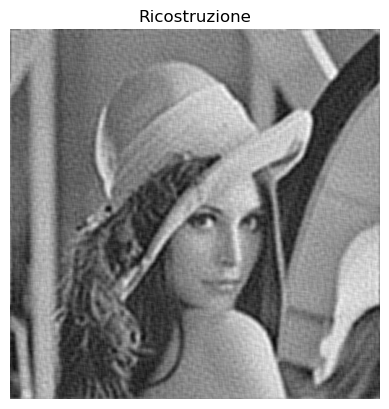

ER 0.0887481056418056
PSNR -21.4376342038562
SSIM 0.5877694400247886


In [ ]:
# Calcolo soluzione regolarizzata con Total Variation 
# problema di minimo risolto con Discesa Gradiente

# Solver per Total Variation
gd_tv_solver = solvers.GDTotalVariation(A, beta=1e-3)

# Scelta parametri TV (beta e lambda)
beta = 1e-3
lmbda = 0.1

# Scelta di x0, kmax, tolf, tolx
x0 = np.zeros_like(x)
kmax = 30
tolf = 1e-8
tolx = 1e-8

# Soluzione
x_TV, obj_val, grad_norm = gd_tv_solver.solve(y_delta, lmbda, x0, kmax, tolf, tolx)

# Visualizzazione ricostruzione
plt.imshow(x_TV, cmap="gray")
plt.axis("off")
plt.title("Ricostruzione")
plt.show()

#Calcolo metriche di errore
print('ER',utilities.rel_err(x_TV,x))
print('PSNR',utilities.psnr(x_TV,x))
print('SSIM',utilities.ssim(x_TV,x))